In [24]:
# Supress Warnings

import warnings
warnings.filterwarnings('ignore')

# Import the numpy and pandas package

import numpy as np
import pandas as pd

# Data Visualisation

import matplotlib.pyplot as plt 
import seaborn as sns

# Read an explore the data

In [25]:
data = pd.read_csv("Housing.csv")
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [27]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


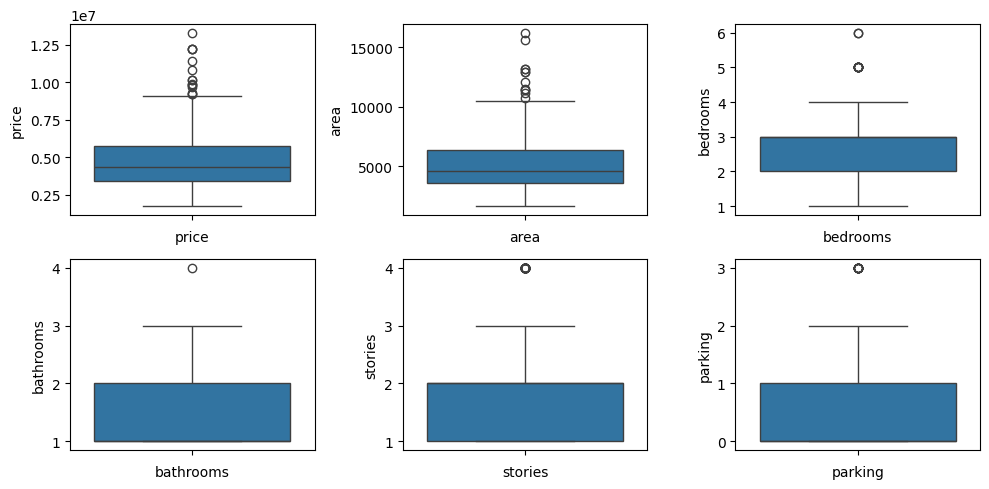

In [28]:
# Outlier Analysis
fig, axs = plt.subplots(2,3, figsize = (10,5))
sns.boxplot(data['price'], ax = axs[0,0]).set(xlabel= 'price')
sns.boxplot(data['area'], ax = axs[0,1]).set(xlabel='area')
sns.boxplot(data['bedrooms'], ax = axs[0,2]).set(xlabel='bedrooms')
sns.boxplot(data['bathrooms'], ax = axs[1,0]).set(xlabel='bathrooms')
sns.boxplot(data['stories'], ax = axs[1,1]).set(xlabel='stories')
sns.boxplot(data['parking'], ax = axs[1,2]).set(xlabel='parking')
plt.tight_layout()
plt.show()

In [29]:
# outlier treatment for price

Q1 = data.price.quantile(0.25) # data['price'].quantile(0.25)
Q3 = data.price.quantile(0.75)
IQR = Q3 - Q1
data = data[(data.price >= Q1 - 1.5*IQR) & (data.price <= Q3 + 1.5*IQR)]
print(Q3,Q1)

5740000.0 3430000.0


In [30]:
len(data)


530

In [31]:
# outlier treatment for area

Q1 = data.area.quantile(0.25)
Q3 = data.area.quantile(0.75)

IQR = Q3 - Q1
data = data[(data.area >= Q1 - 1.5*IQR) & (data.area <= Q3 + 1.5*IQR)]

In [32]:
len(data)

517

In [33]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

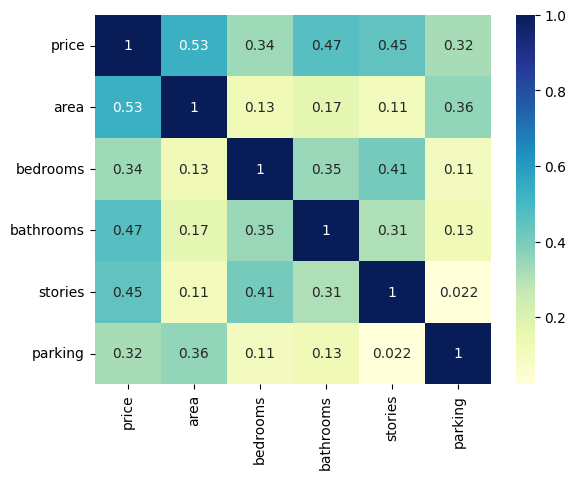

In [34]:
#Correlation of output with numerical variables

# plotting correlation heatmap
dataplot = sns.heatmap(data[['price', 'area', 'bedrooms', 'bathrooms', 'stories','parking']].corr(), cmap="YlGnBu", annot=True)
# displaying heatmap
plt.show()

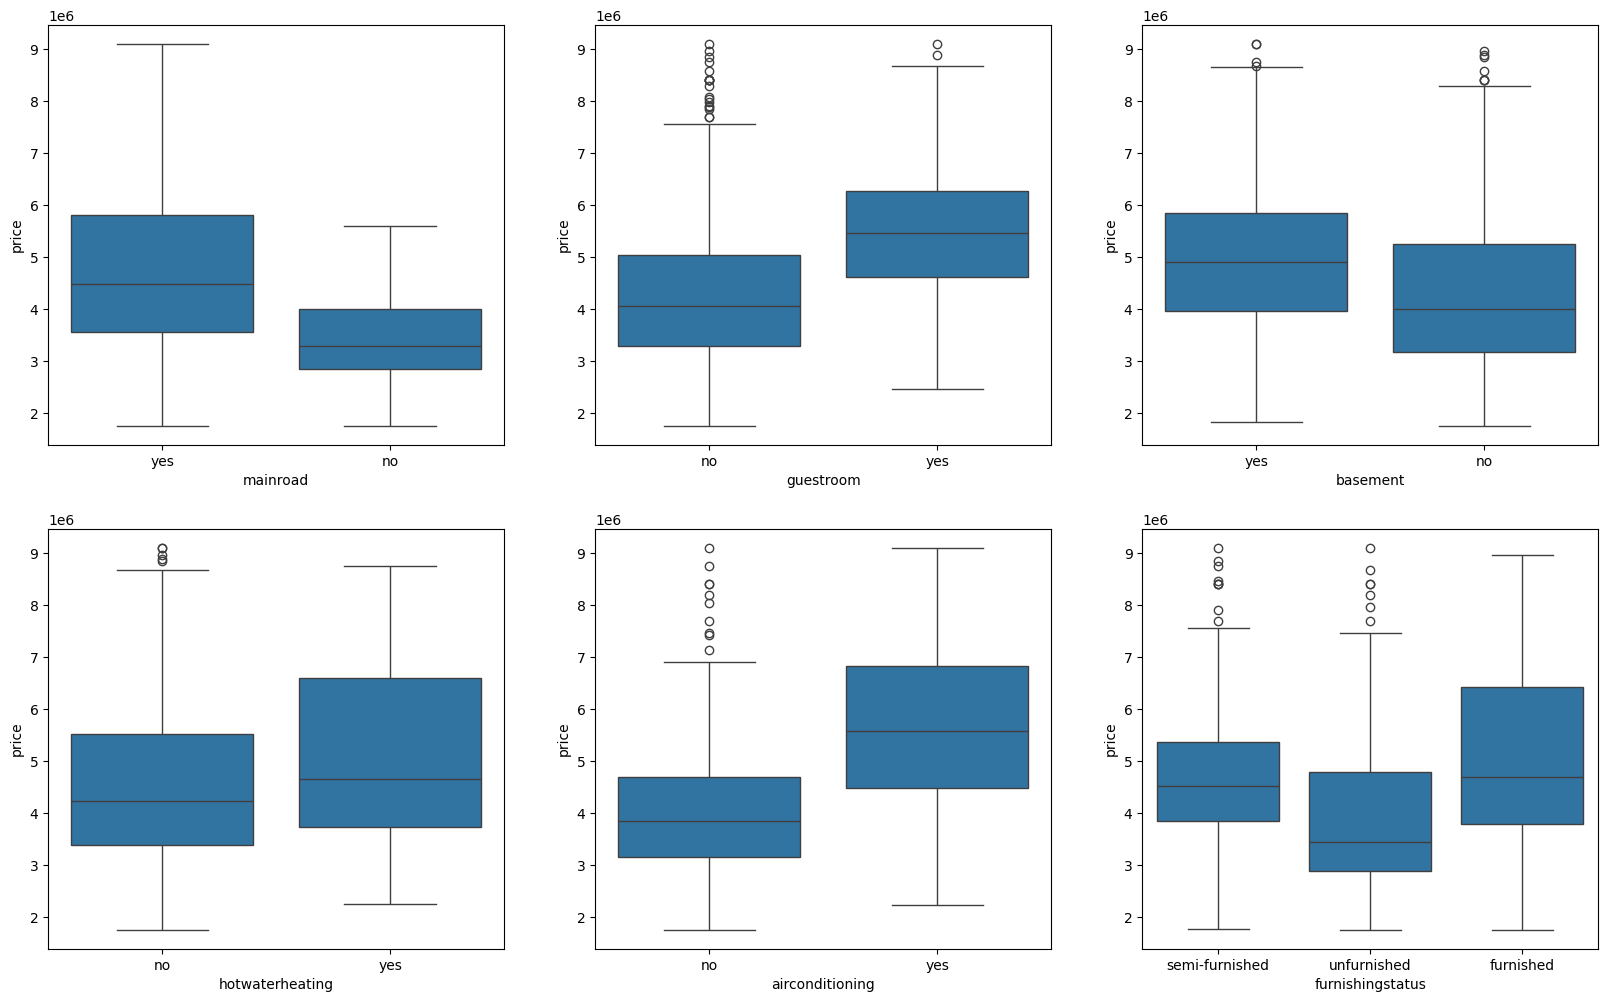

In [35]:
#Visualizing categorical variables

plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.boxplot(x = 'mainroad', y = 'price', data = data)
plt.subplot(2,3,2)
sns.boxplot(x = 'guestroom', y = 'price', data = data)
plt.subplot(2,3,3)
sns.boxplot(x = 'basement', y = 'price', data = data)
plt.subplot(2,3,4)
sns.boxplot(x = 'hotwaterheating', y = 'price', data = data)
plt.subplot(2,3,5)
sns.boxplot(x = 'airconditioning', y = 'price', data = data)
plt.subplot(2,3,6)
sns.boxplot(x = 'furnishingstatus', y = 'price', data = data)
plt.show()

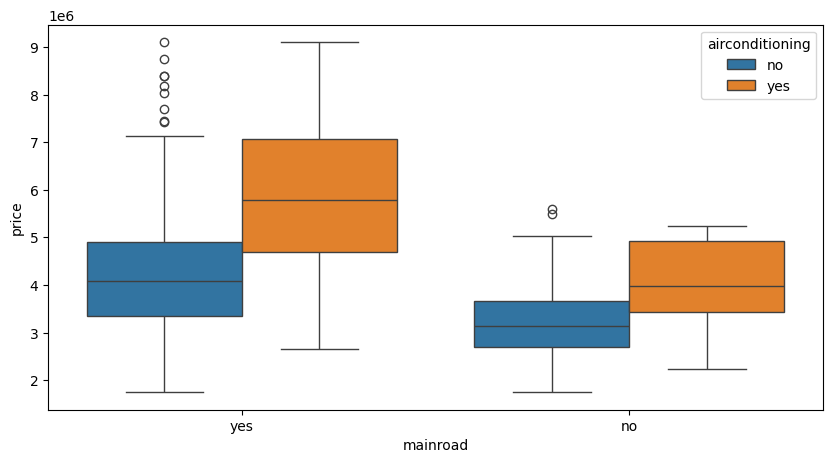

In [36]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = 'mainroad', y = 'price', hue = 'airconditioning', data = data)
plt.show()

# Convert data to features

In [37]:
# List of variables to map

cat_features =  ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Defining the map function
def create_features(x):
    return x.map({'yes': 1, "no": 0})

# Applying the function to the housing list
data[cat_features] = data[cat_features].apply(create_features)

In [38]:
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,unfurnished
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,furnished
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,furnished
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,semi-furnished
20,8750000,4320,3,1,2,1,0,1,1,0,2,0,semi-furnished
21,8680000,7155,3,2,1,1,1,1,0,1,2,0,unfurnished
22,8645000,8050,3,1,1,1,1,1,0,1,1,0,furnished
23,8645000,4560,3,2,2,1,1,1,0,1,1,0,furnished
24,8575000,8800,3,2,2,1,0,0,0,1,2,0,furnished


In [39]:
#Create dummy features for categorical variables

data_cat = pd.get_dummies(data['furnishingstatus'],drop_first=True)

In [40]:
data_cat.head(100)

,semi-furnished,unfurnished
15,True,False
16,False,True
17,False,False
18,False,False
19,True,False
...,...,...
115,True,False
116,False,True
117,False,False
118,False,False


In [41]:

data = pd.concat([data, data_cat], axis = 1)
data.drop(['furnishingstatus'], axis = 1, inplace = True)
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,True,False
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,False,True
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,False,False
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,False,False
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,True,False
20,8750000,4320,3,1,2,1,0,1,1,0,2,0,True,False
21,8680000,7155,3,2,1,1,1,1,0,1,2,0,False,True
22,8645000,8050,3,1,1,1,1,1,0,1,1,0,False,False
23,8645000,4560,3,2,2,1,1,1,0,1,1,0,False,False
24,8575000,8800,3,2,2,1,0,0,0,1,2,0,False,False


# Train test split and Data Scaling

In [42]:
from sklearn.model_selection import train_test_split

#np.random.seed(0) # not must to do
df_train, df_test = train_test_split(data, train_size = 0.8, test_size = 0.2, random_state = 100)

In [43]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [44]:
# Apply scaler() to all the columns except the 'yes-no' and 'dummy' variables
num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])


In [45]:
df_train.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,4.130000e+02,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.00000,413.000000,413.000000,413.000000,413.000000
mean,4.543525e+06,0.360160,0.387893,0.128329,0.259080,0.871671,0.162228,0.35109,0.046005,0.292978,0.217111,0.200969
std,1.569223e+06,0.200796,0.149915,0.229492,0.280384,0.334862,0.369107,0.47789,0.209750,0.455681,0.281482,0.401211
min,1.750000e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.423000e+06,0.207852,0.200000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,4.200000e+06,0.306236,0.400000,0.000000,0.333333,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,5.530000e+06,0.496536,0.400000,0.000000,0.333333,1.000000,0.000000,1.00000,0.000000,1.000000,0.333333,0.000000
max,9.100000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [46]:
df_test[num_vars] = scaler.transform(df_test[num_vars])

In [47]:
df_test.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,1.040000e+02,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,4.669533e+06,0.400988,0.390385,0.139423,0.288462,0.769231,0.240385,0.326923,0.028846,0.365385,0.221154,0.278846
std,1.696879e+06,0.220979,0.131842,0.245906,0.318633,0.423365,0.429386,0.471361,0.168185,0.483870,0.281047,0.450603
min,1.890000e+06,-0.005774,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.353000e+06,0.235277,0.400000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.427500e+06,0.374134,0.400000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.635000e+06,0.548066,0.400000,0.500000,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,0.333333,1.000000
max,9.100000e+06,0.986143,0.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [48]:
y_train = df_train.pop('price') # df_train['price'] #labels in training data
x_train = df_train # features in training data

In [49]:
y_test = df_test.pop('price') # df_test['price'] #lables in test data
x_test = df_test # features in test data

# Fit the Linear Regression Model

In [50]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_train, y_train) # training

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
help(LinearRegression)

Help on class LinearRegression in module sklearn.linear_model._base:

class LinearRegression(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, LinearModel)
 |  LinearRegression(*, fit_intercept=True, copy_X=True, tol=1e-06, n_jobs=None, positive=False)
 |  
 |  Ordinary least squares Linear Regression.
 |  
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |  
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |  
 |  copy_X : bool, default=True
 |      If True, X will be copied; else, it may be overwritten.
 |  
 |  tol : float, default=1e-6
 |      The precision of the solution (`coef_`) is determined by `tol` w

In [52]:
#Let's see the summary of our linear model
print(lr_model.coef_)

[2527088.9929434   193000.69186717 1520868.29320012 1471086.25857166
  387163.28407339  107665.08808556  320841.59283444  759920.54717187
  657331.9144279   517028.53121592  627668.26091734  -27828.72692791
 -407917.30736564]


In [53]:
# this is for our understanding - not needed for LR model
import numpy as np
importance = np.array(lr_model.coef_)
importance = importance / sum(importance)
print(importance )

[ 0.29201677  0.02230212  0.17574333  0.16999079  0.0447385   0.0124412
  0.03707472  0.08781232  0.07595773  0.05974503  0.07252996 -0.00321574
 -0.04713672]


In [54]:
for z in range(len(list(x_train.columns))):
    print("The Importance coefficient for {} is {}".format(x_train.columns[z], importance[z]))

The Importance coefficient for area is 0.2920167676671609
The Importance coefficient for bedrooms is 0.022302118506294304
The Importance coefficient for bathrooms is 0.1757433332454539
The Importance coefficient for stories is 0.1699907899512961
The Importance coefficient for mainroad is 0.044738499946071146
The Importance coefficient for guestroom is 0.012441196610463206
The Importance coefficient for basement is 0.037074723183203616
The Importance coefficient for hotwaterheating is 0.087812317844226
The Importance coefficient for airconditioning is 0.07595772902011222
The Importance coefficient for parking is 0.059745027143471977
The Importance coefficient for prefarea is 0.0725299572876794
The Importance coefficient for semi-furnished is -0.003215737517939589
The Importance coefficient for unfurnished is -0.04713672288749311


In [55]:
print(lr_model.intercept_)

2189813.385515329


In [56]:
x_train.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'semi-furnished', 'unfurnished'],
      dtype='object')

# Residual Analysis

In [57]:
#residual analysis
#Residual analysis is typically performed on the training data rather than the test data. 
#The purpose of residual analysis is to assess the performance and
#assumptions of your regression model during the training phase.

In [58]:
y_train_pred = lr_model.predict(x_train)
residuals = (y_train_pred - y_train)

<Axes: xlabel='price', ylabel='Density'>

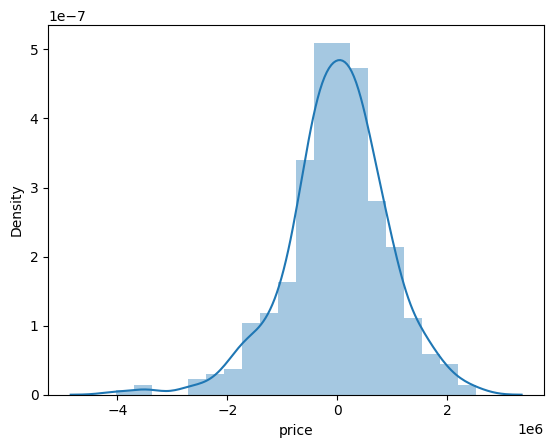

In [ ]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot(residuals, bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)                         # X-label

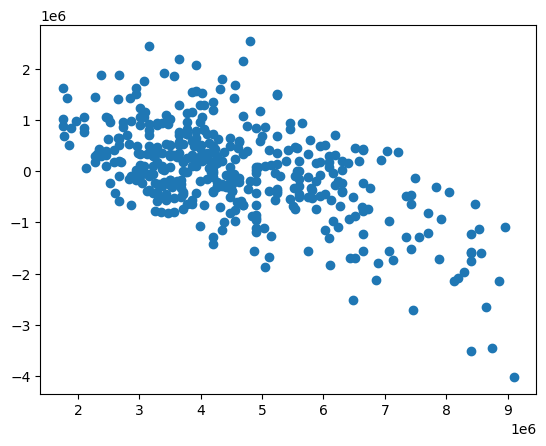

In [ ]:
plt.scatter(y_train,residuals)
plt.show()
# Model is giving negative error in high house price range and postive error in low house price range
# Its estimating a bit higher prices for houses with lower prices and lower pricess for houses with higher prices
# We might need more data or the relatioship between input and ouput is not necessarily linear in all regions
# In the region where model is doing fine ( residual around 0) - we do have lot of data points

# Create predictions and evaluate model

In [61]:
# Making predictions
y_test_pred = lr_model.predict(x_test)

In [62]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_percentage_error
r2_score(y_test, y_test_pred)

0.6463757490565982

In [63]:
mean_absolute_percentage_error(y_test, y_test_pred)

0.17229590487390156

In [64]:
# Less than ~20% average percentage error is not a bad result on such a small dataset
# Results would improve if we get more data to train the model
# Some additional fetaures like distance from best school, shoppig and entertainment options etc would also help

Text(0, 0.5, 'y_test_pred')

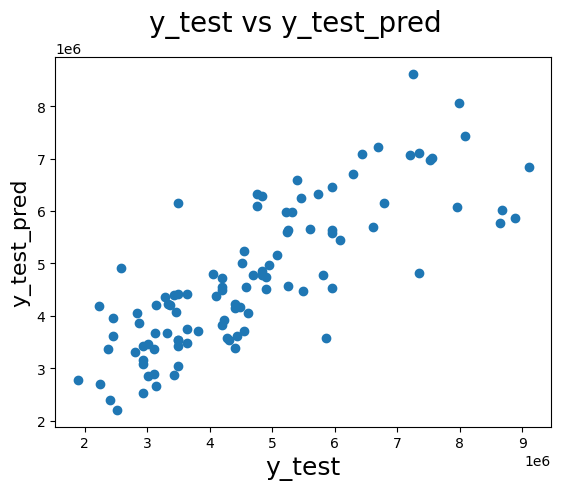

In [65]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test,y_test_pred)
fig.suptitle('y_test vs y_test_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_test_pred', fontsize=16)                          # Y-label